In [1]:
import spatialdata as sd
from spatialdata_io import xenium

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

import pandas as pd 

In [2]:
xenium_path = ["../data/rep1/outs", "../data/rep2/outs"]
zarr_path = ["../data/rep1.zarr","../data/rep2.zarr"]

In [5]:
sdata  = {}
adata_spa = {}
for entry in range(len(zarr_path)):
    sdata[entry] = sd.read_zarr(zarr_path[entry])
    adata_spa[entry] = sdata[entry].tables["table"]

    adata_spa[entry].obs.index = [str(entry2) for entry2 in adata_spa[entry].obs.index]

    adata_spa[entry].obs['sample'] = 'rep' + str(entry + 1)

    sparep_anno = pd.read_csv("../data/dataset12_enium_rep" + str(entry + 1) + "_sup_anno_.csv")
    # sparep_anno.index.name = 'cell_id'
    adata_spa[entry].obs['celltype'] = sparep_anno['Cluster'].values


version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04
/project/mlobo6/miniconda3/envs/spadecoder/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04
/project/mlobo6/miniconda3/envs/spadecoder/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [6]:
adata_spa

{0: AnnData object with n_obs × n_vars = 167780 × 313
     obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'sample', 'celltype'
     var: 'gene_ids', 'feature_types', 'genome'
     uns: 'spatialdata_attrs'
     obsm: 'spatial',
 1: AnnData object with n_obs × n_vars = 118752 × 313
     obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'sample', 'celltype'
     var: 'gene_ids', 'feature_types', 'genome'
     uns: 'spatialdata_attrs'
     obsm: 'spatial'}

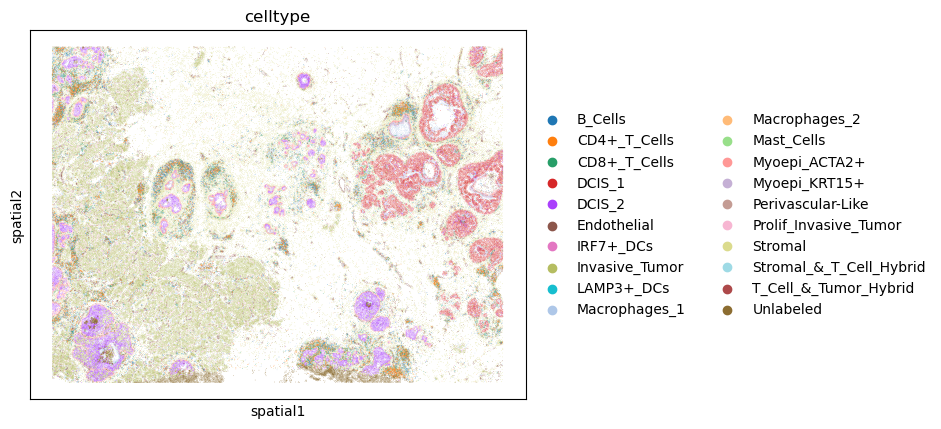

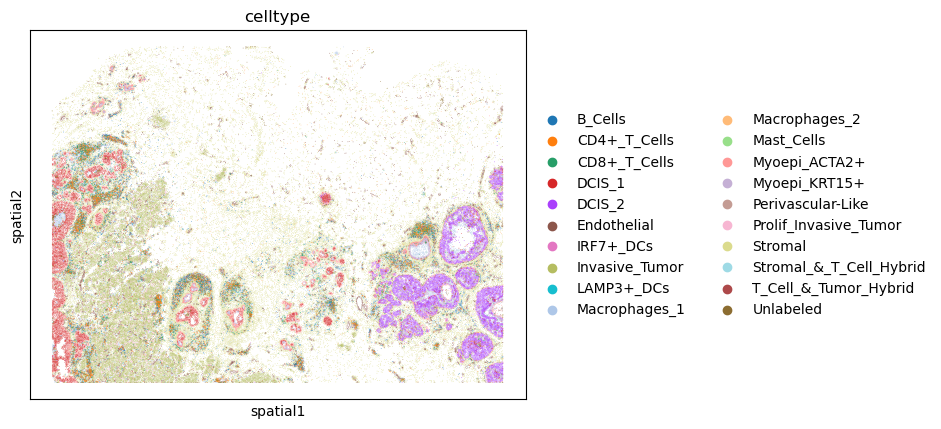

In [7]:
for entry in adata_spa.keys():
    sc.pl.embedding(adata_spa[entry],'spatial',color='celltype')

In [8]:
adata_spa[0].obs['celltype'].cat.categories

Index(['B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2',
       'Endothelial', 'IRF7+_DCs', 'Invasive_Tumor', 'LAMP3+_DCs',
       'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+',
       'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor',
       'Stromal', 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid',
       'Unlabeled'],
      dtype='object')

In [9]:
adata_spa[1].obs['celltype'].cat.categories

Index(['B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2',
       'Endothelial', 'IRF7+_DCs', 'Invasive_Tumor', 'LAMP3+_DCs',
       'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+',
       'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor',
       'Stromal', 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid',
       'Unlabeled'],
      dtype='object')

In [ ]:
# fix swap in DCIS1 and DCIS2 as mentioned by authors 
adata_spa[1].rename_categories('celltype',['B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_2', 'DCIS_1',
       'Endothelial', 'IRF7+_DCs', 'Invasive_Tumor', 'LAMP3+_DCs',
       'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+',
       'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor',
       'Stromal', 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid',
       'Unlabeled'])

In [11]:
adata_spa[1].uns['celltype_colors'] = ['#1f77b4',
 '#ff7f0e',
 '#279e68','#aa40fc',
 '#d62728',
 
 '#8c564b',
 '#e377c2',
 '#b5bd61',
 '#17becf',
 '#aec7e8',
 '#ffbb78',
 '#98df8a',
 '#ff9896',
 '#c5b0d5',
 '#c49c94',
 '#f7b6d2',
 '#dbdb8d',
 '#9edae5',
 '#ad494a',
 '#8c6d31']

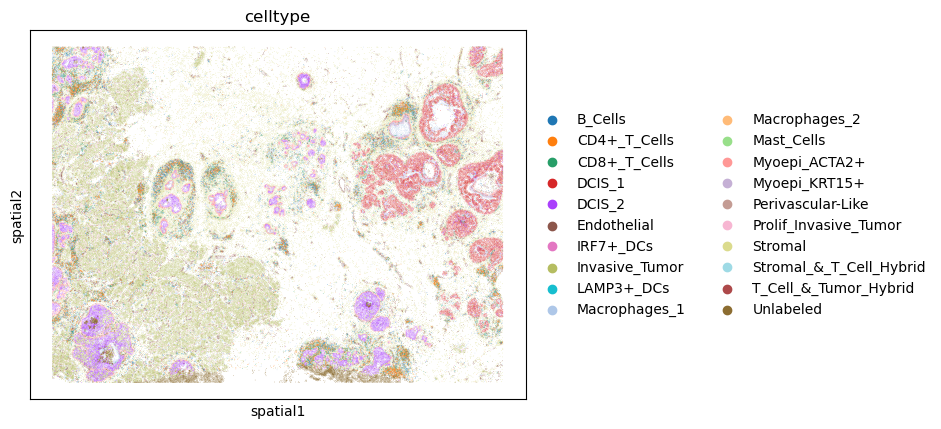

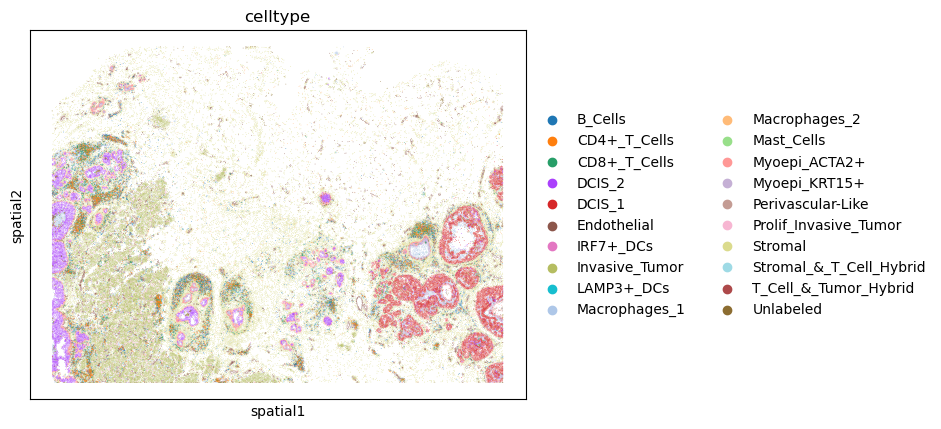

In [12]:
## bug in annotations - swap DCIS_1 and DCIS_2 in cell-type 2; also change color 

for entry in adata_spa.keys():
    sc.pl.embedding(adata_spa[entry],'spatial',color='celltype')

In [13]:

# adata_concat = adata_spa[0].concatenate(adata_spa[1])

In [14]:
marker_genes = {'Tumor':['FASN','FOXA1','CEACAM6','GATA3','MZB1','AGR3','SERPINA3','TACSTD2','ABCC11','MKI67'],
                'Myoepithelial':['KRT23','ALDH1A3','SFRP1','KRT15','MYLK','ACTA2'],
                'Stromal':['GJB2','SFRP4','POSTN','MMP2'],
                'Tcells':['CXCR4','CD8A','TRAC','CD4'],
                'Bcells':['MS4A1','BANK1'],
                'Macrophages':['APOC1','MMP12','C15orf48','ITGAX','CD68'],
                'Endothelial':['LRRC15','AQP1','VWF','PECAM1']}

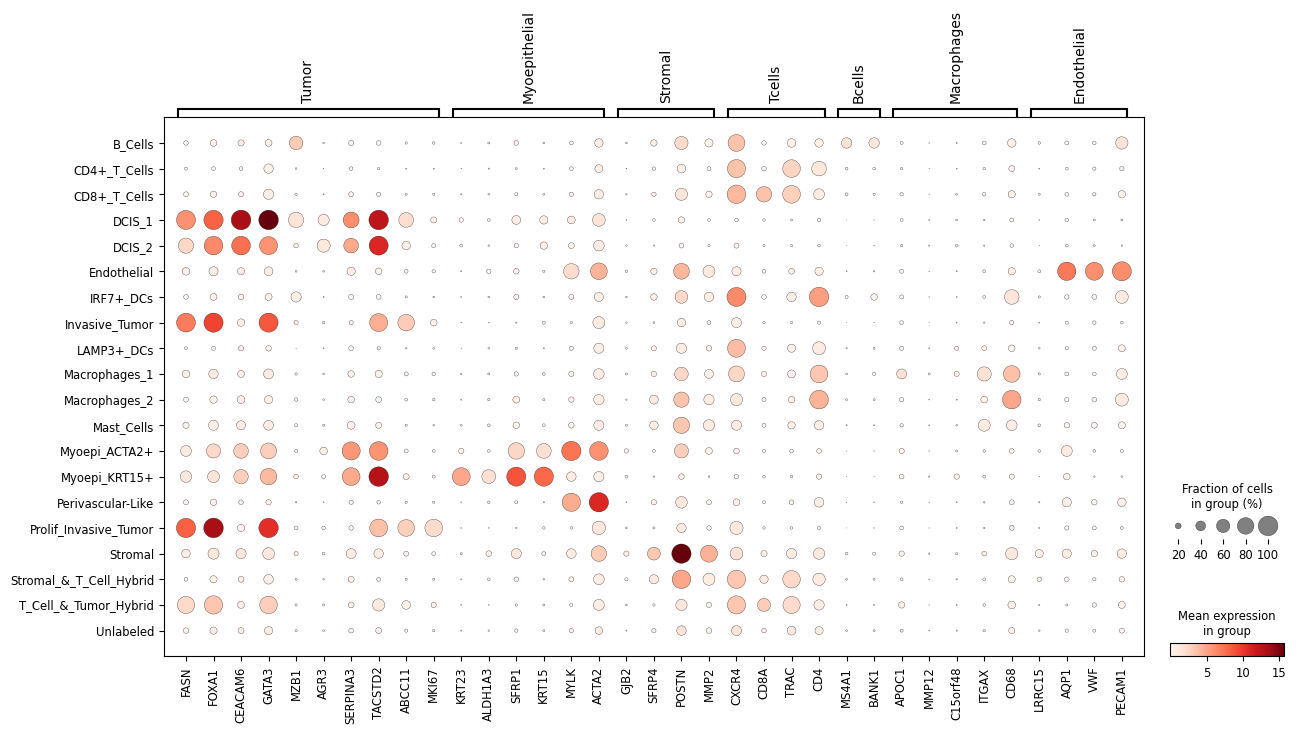

In [18]:
sc.pl.dotplot(adata_spa[0],marker_genes,groupby='celltype')

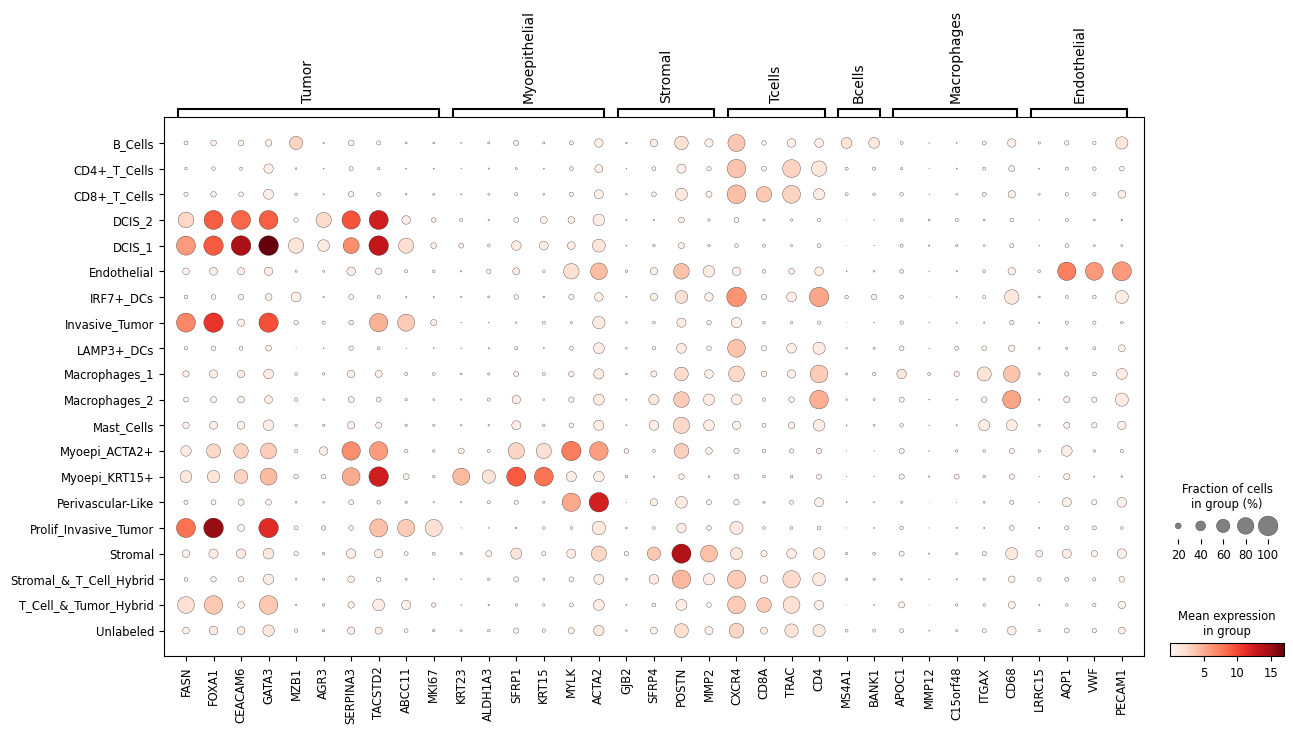

In [19]:
sc.pl.dotplot(adata_spa[1],marker_genes,groupby='celltype')

In [20]:
scrna_filepath = '../data/scRNA/'
adata = sc.read_10x_h5(scrna_filepath + 'Chromium_FFPE_Human_Breast_Cancer_Chromium_FFPE_Human_Breast_Cancer_count_sample_filtered_feature_bc_matrix.h5')
scrna_anno = pd.read_csv("../data/dataset12_scRNA_anno_.csv",index_col=0)
scrna_anno.index.name = None
print(len(scrna_anno.index), len(set(scrna_anno.index)))
print(len(adata.obs.index), len(set(adata.obs.index)))
to_keep = list(set(scrna_anno.index).intersection(set(adata.obs.index) ))
adata = adata[to_keep,:]

scrna_anno = scrna_anno.loc[to_keep, ]
scrna_anno
adata.obs['celltype'] = scrna_anno['Annotation'].values

/project/mlobo6/miniconda3/envs/spadecoder/lib/python3.12/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/project/mlobo6/miniconda3/envs/spadecoder/lib/python3.12/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/tmp/ipykernel_3660785/773431266.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['celltype'] = scrna_anno['Annotation'].values


27472 27472
30365 30365


/project/mlobo6/miniconda3/envs/spadecoder/lib/python3.12/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/project/mlobo6/miniconda3/envs/spadecoder/lib/python3.12/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [21]:
# read the UMPA file from 10X 
umap_coords = pd.read_csv(scrna_filepath + "analysis/umap/gene_expression_2_components/projection.csv",index_col=0)

umap_coords = umap_coords.loc[to_keep,:]

adata.obsm['X_umap'] = umap_coords.values

In [22]:
# read the UMPA file from 10X 
tsne_coords = pd.read_csv(scrna_filepath + "analysis/tsne/gene_expression_2_components/projection.csv",index_col=0)

tsne_coords = tsne_coords.loc[to_keep,:]

adata.obsm['X_tsne'] = tsne_coords.values

In [23]:
adata

AnnData object with n_obs × n_vars = 27460 × 18082
    obs: 'celltype'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'X_umap', 'X_tsne'

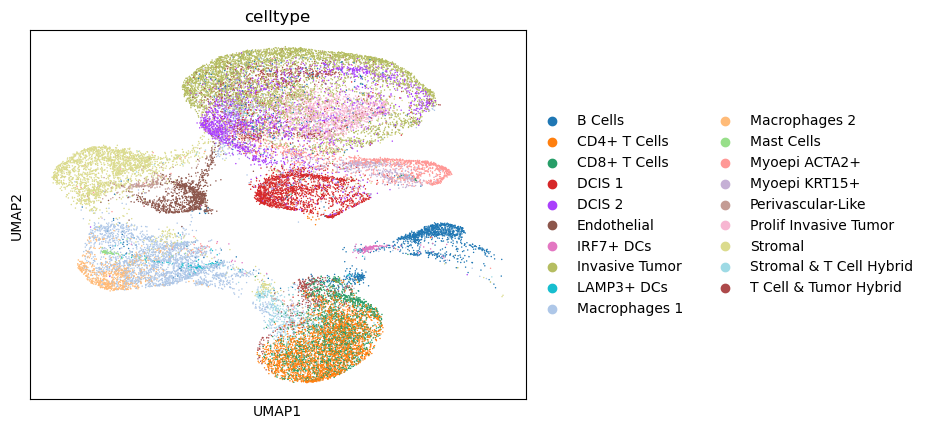

In [24]:
sc.pl.umap(adata,color='celltype')

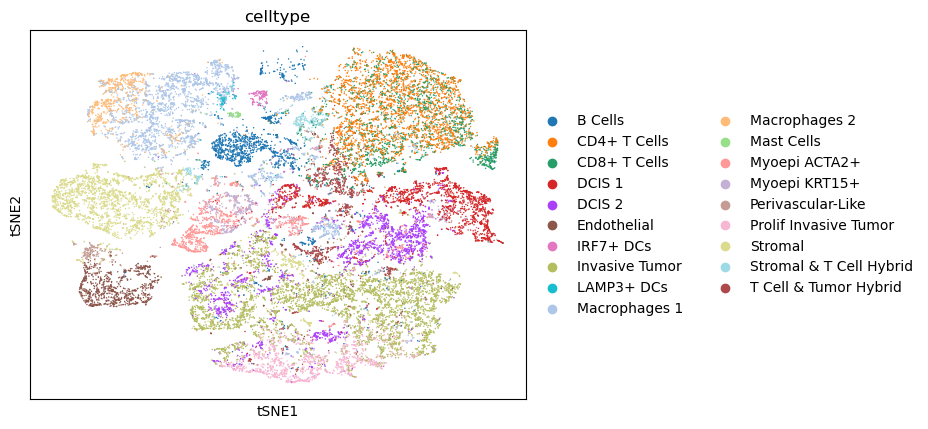

In [25]:
sc.pl.tsne(adata,color='celltype')

In [27]:
## rename reference cell types 
adata.rename_categories('celltype',['B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2',
       'Endothelial', 'IRF7+_DCs', 'Invasive_Tumor', 'LAMP3+_DCs',
       'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+',
       'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor',
       'Stromal', 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid'])

In [28]:
adata = adata[~adata.obs['celltype'].isin(['Stromal_&_T_Cell_Hybrid','T_Cell_&_Tumor_Hybrid'])]

In [29]:
common_celltypes = list(set(adata.obs['celltype'].values).intersection(adata_spa[0].obs['celltype'].values))



In [30]:
print(len(common_celltypes), len(set(adata.obs['celltype'].values)), len(set(adata_spa[0].obs['celltype'].values))) # unlabelled dropped 

17 17 20


In [31]:
for entry in adata_spa.keys():
    # sc.pl.embedding(adata_spa[entry],'spatial',color='celltype',groups='Unlabeled')

    adata_spa[entry] = adata_spa[entry][adata_spa[entry].obs['celltype'].isin(common_celltypes)]

In [32]:
print(len(common_celltypes), len(set(adata.obs['celltype'].values)), len(set(adata_spa[1].obs['celltype'].values))) # unlabelled dropped 

17 17 17


In [33]:
adata.obs['celltype'].cat.categories

Index(['B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2',
       'Endothelial', 'IRF7+_DCs', 'Invasive_Tumor', 'LAMP3+_DCs',
       'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+',
       'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor',
       'Stromal'],
      dtype='object')

In [34]:
adata

View of AnnData object with n_obs × n_vars = 26031 × 18082
    obs: 'celltype'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'celltype_colors'
    obsm: 'X_umap', 'X_tsne'

In [35]:
adata_spa

{0: View of AnnData object with n_obs × n_vars = 158030 × 313
     obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'sample', 'celltype'
     var: 'gene_ids', 'feature_types', 'genome'
     uns: 'spatialdata_attrs', 'celltype_colors'
     obsm: 'spatial',
 1: View of AnnData object with n_obs × n_vars = 114483 × 313
     obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'sample', 'celltype'
     var: 'gene_ids', 'feature_types', 'genome'
     uns: 'spatialdata_attrs', 'celltype_colors'
     obsm: 'spatial'}

In [ ]:
 # doesnt remove any cells 
# sc.pp.filter_cells(adata,min_counts=5)


# for entry in adata_spa.keys():
#     sc.pp.filter_cells(adata_spa[entry],min_counts=5)

/project/mlobo6/miniconda3/envs/spadecoder/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number
/project/mlobo6/miniconda3/envs/spadecoder/lib/python3.12/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/project/mlobo6/miniconda3/envs/spadecoder/lib/python3.12/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/project/mlobo6/miniconda3/envs/spadecoder/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number
/project/mlobo6/miniconda3/envs/spadecoder

In [37]:
adata.var_names_make_unique()

In [38]:
adata_spa

{0: AnnData object with n_obs × n_vars = 158030 × 313
     obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'sample', 'celltype', 'n_counts'
     var: 'gene_ids', 'feature_types', 'genome'
     uns: 'spatialdata_attrs', 'celltype_colors'
     obsm: 'spatial',
 1: AnnData object with n_obs × n_vars = 114483 × 313
     obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'sample', 'celltype', 'n_counts'
     var: 'gene_ids', 'feature_types', 'genome'
     uns: 'spatialdata_attrs', 'celltype_colors'
     obsm: 'spatial'}

In [39]:
adata

AnnData object with n_obs × n_vars = 26031 × 18082
    obs: 'celltype', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'celltype_colors'
    obsm: 'X_umap', 'X_tsne'

## fix annotations 

In [37]:
ct_reanno = {'Invasive_Tumor':'Tumor', # InvTumor
             'Macrophages_1':'Macrophages',
             'Macrophages_2':'Macrophages',
             'CD4+_T_Cells':'TCells',
             'Stromal':'Stromal',
             'DCIS_2':'Tumor',# 'DCIS',
             'DCIS_1':'Tumor', # 'DCIS',
             'CD8+_T_Cells':'TCells',
             'B_Cells':'BCells',
             'Prolif_Invasive_Tumor':'Tumor',# 'InvTumor',
             'Myoepi_ACTA2+':'Myoepithelial',
                'Myoepi_KRT15+':'Myoepithelial',
                'Endothelial':'Endothelial',
             'Perivascular-Like':'Perivascular-Like',
               'IRF7+_DCs':'DCs',
               'LAMP3+_DCs':'DCs',
               'Mast_Cells':'Mast'
             }

In [ ]:

scrna_reanno = []
for entry in adata.obs['celltype'].values:
    scrna_reanno.append(ct_reanno[entry])
adata.obs['Anno'] = scrna_reanno

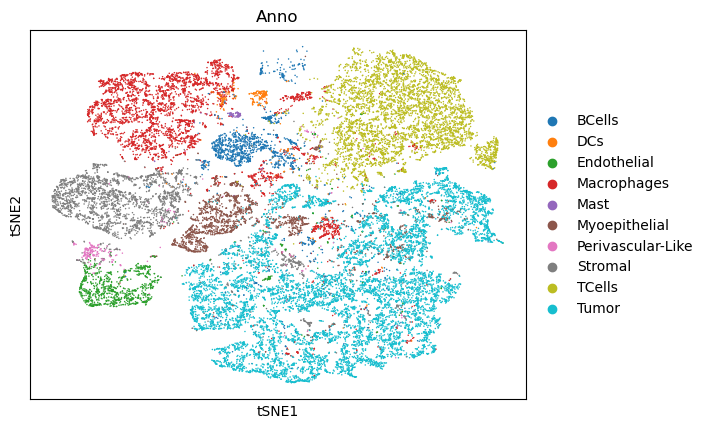

In [39]:
sc.pl.tsne(adata,color='Anno')

In [40]:
for entry in adata_spa.keys():
    spa_reanno = []
    for entry2 in adata_spa[entry].obs['celltype'].values:
        spa_reanno.append(ct_reanno[entry2])
    adata_spa[entry].obs['Anno'] = spa_reanno
    

In [48]:
adata.uns['Anno_colors'] = ['#1f77b4',
 '#98df8a',
 '#279e68','#aa40fc',
 
 
 '#8c564b',
 '#e377c2',
 '#b5bd61',
 '#17becf',
#  '#aec7e8',
 # '#ffbb78',

  '#ff7f0e',
 '#d62728',
 ]

In [52]:
for entry in adata_spa.keys():
    adata_spa[entry].uns['Anno_colors'] = ['#1f77b4',    '#98df8a'

    '#279e68','#aa40fc',
    
    
    '#8c564b',
    '#e377c2',
    '#b5bd61',
    '#17becf',
   #  '#aec7e8',
    # '#ffbb78',
        '#ff7f0e',
'#d62728',
    ]

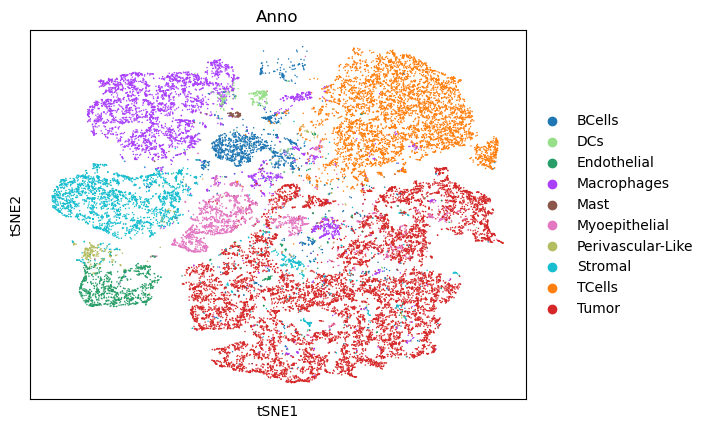

In [53]:
sc.pl.tsne(adata,color='Anno')

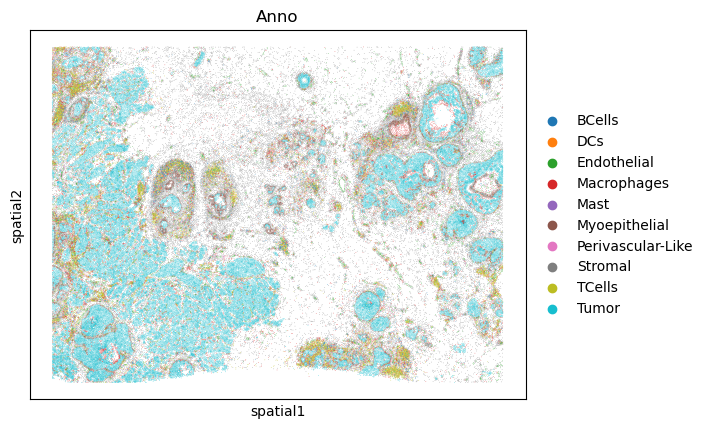

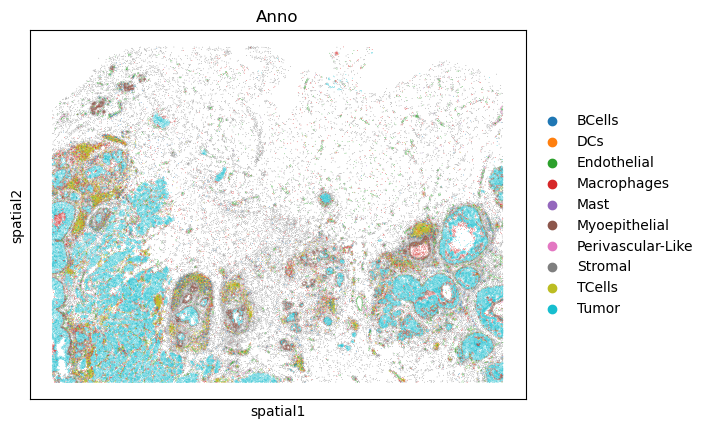

In [54]:

for entry in adata_spa.keys():
    sc.pl.embedding(adata_spa[entry],'spatial',color='Anno')

In [55]:
import pickle 
adata.write_h5ad("../data/scRNA_raw.h5ad")


with open('../data/spatial_raw.pickle', 'wb') as handle:
    pickle.dump(adata_spa, handle, protocol=pickle.HIGHEST_PROTOCOL)


## Run simulation

## READING DONE 

In [8]:
N_range = [50]#[5, 10, 20, 50,  75, 100, 150,  250,  400, 500] #[5, 50, 500] # [5, 10, 20] # , 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500] # [500] # [5, 10, 50] # [100, 250] # [500]   # [5, 10, 20, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500]
numcells_to_swap_range = [2] # , 16] #[0, 2, 8, 16, 64, 250]
nneigh = 10


In [9]:

import scanpy as sc 

import anndata

import pickle

In [ ]:
# perform QC for reference based on 1st spatial sample 

spa_celltype_key='Anno'


scrna_cluster_key = "Anno"


adata_sc = sc.read("../data/scRNA_raw.h5ad")

common_celltypes = ['BCells',  'DCs', 'Endothelial', 'Tumor', 'Macrophages',
       'Mast', 'Myoepithelial', 'Perivascular-Like', 'Stromal', 'TCells'] # define this according to dataset

savesimdir = '../results/simulations/pickles/'

save_sim_file = savesimdir + 'multi_slice_simulated_sptsz_' + str(N_range[0]) + '_nneigh_' + str(nneigh)  + '_nbdswaps_' + str(numcells_to_swap_range[0]) + '.pickle'


with open(save_sim_file, 'rb') as handle:
    tmpa = pickle.load(handle)  
entry0 = list(tmpa.keys())[0]
entry1 = list(tmpa[entry0].keys())[0]
entry2 = list(tmpa[entry0][entry1].keys())[0]

genes_to_use = list((set(tmpa[entry0][entry1][entry2].var.index).intersection(set(adata_sc.var.index))))
print(len(genes_to_use))
genes_to_use.sort()

print(adata_sc.to_df().sum(axis=1).median())

adata_sc =  anndata.AnnData(X=adata_sc.to_df()[genes_to_use],obs=adata_sc.obs,uns=adata_sc.uns,obsm=adata_sc.obsm)
sc.pp.filter_cells(adata_sc,min_counts=1)

print(adata_sc.to_df().sum(axis=1).median())

norm_fac = adata_sc.to_df().sum(axis=1)

sc.pp.normalize_total(adata_sc, target_sum=1000)

print(adata_sc.to_df().sum(axis=1).median())

# sc.pp.log1p(adata_sc)

print(adata_sc.to_df().sum(axis=1).median())

adata_sc = adata_sc[adata_sc.obs[scrna_cluster_key].isin(common_celltypes)]




if adata_sc.shape[1] > 1500:
    
    sc.tl.rank_genes_groups(adata_sc, groupby=scrna_cluster_key, method="wilcoxon")
    sc.tl.filter_rank_genes_groups(adata_sc,   key_added='rank_genes_groups_filtered',  min_fold_change=1.5)
    all_genes = sc.get.rank_genes_groups_df(adata_sc,group=None, key='rank_genes_groups_filtered', pval_cutoff=0.05, log2fc_min=1.5)
    all_genes = all_genes[~all_genes['names'].isna()]
    adata_sc = adata_sc[:,list(set(all_genes['names']))]
    disp_columns = []
    for ct in set(adata_sc.obs[scrna_cluster_key].values):
        adata_sc.var[ct + '_disperson'] = 0.0
        disp_columns.append(ct + '_disperson')
        tmpa = adata_sc[adata_sc.obs[scrna_cluster_key]==ct].copy()

        tmpb = tmpa.to_df().var() / (tmpa.to_df().mean() + 0.000001)

        adata_sc.var[ct + '_disperson'] = tmpb


    adata_sc.var['avg_dispersion'] = adata_sc.var[disp_columns].mean(axis=1)
    import numpy as np
    top_pct = np.quantile(a=adata_sc.var['avg_dispersion'], q=0.99)

    adata_sc = adata_sc[:,adata_sc.var['avg_dispersion'] < top_pct]
    
# del adata_sc.uns
adata_sc.write_h5ad("../data/scrna_ref_norm1knolog.h5ad")


# adata_sc.write_h5ad("../data/scrna_ref_failednorm_nov2024.h5ad")


307
2339.0
84.0
1000.0
1000.0


In [12]:
norm_fac.to_csv("../data/normalization_factors_for_scrna_use_in_spatial_gene_expr_pred.csv")

In [ ]:

#cnt = 0

nneigh_range = [10]
N_range = [50] #[25,  75,  125, 150, 175] # [5, 10, 50,  100,  200,  400] #[5, 50, 500] # [5, 10, 20] # , 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500] # [500] # [5, 10, 50] # [100, 250] # [500]   # [5, 10, 20, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500]
nswaps_nbd_range = [2] # [2, 5, 10, 20, 50, 100]

for N in N_range:
        # for linear_slope_variance in linear_slope_variance_range:#[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        #     for linear_intercept_variance in linear_intercept_variance_range: # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        for nneigh in nneigh_range:#[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
            for nbdswaps in nswaps_nbd_range: # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
                # for numcells_to_swap in numcells_to_swap_range:#[0, 2, 4, 8, 16, 32, 64, 128, 256]:
                    # save_sim_file = savesimdir + 'warped_spots_simulated_' + str(N) + '_linear_slope_var_' + str(linear_slope_variance) + '_linear_int_var_' + str(linear_intercept_variance) + '_' + str(numcells_to_swap) + '.pickle'
                    # write_sim_file = savesimdir + 'warped_spots_simulated_' + str(N) + '_linear_slope_var_' + str(linear_slope_variance) + '_linear_int_var_' + str(linear_intercept_variance) + '_' + str(numcells_to_swap) + '_normnolog_nov2024_1k.pickle'
                    save_sim_file = savesimdir + 'multi_slice_simulated_sptsz_' + str(N) +  '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '.pickle'
                    write_sim_file = savesimdir + 'multi_slice_simulated_sptsz_' + str(N) +  '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_norm1knolog.pickle'
                    
                    
                    with open(save_sim_file, 'rb') as handle:
                        adata_spot_swap = pickle.load(handle)

                    for entry0 in adata_spot_swap.keys():
                        for entry1 in adata_spot_swap[entry0].keys(): 
                            for entry2 in adata_spot_swap[entry0][entry1].keys():
                                #adata_st = adata_spot_swap[entry0][entry1][entry2].copy()
                                


                                genes_to_use = list((set(adata_sc.var.index).intersection(set(adata_spot_swap[entry0][entry1][entry2].var.index))))
                                # print(len(genes_to_use))
                                genes_to_use.sort()

                                
                                adata_st =  anndata.AnnData(X=adata_spot_swap[entry0][entry1][entry2].to_df()[genes_to_use],obs=adata_spot_swap[entry0][entry1][entry2].obs,uns=adata_spot_swap[entry0][entry1][entry2].uns,obsm=adata_spot_swap[entry0][entry1][entry2].obsm)

                                

                                print(adata_st.to_df().sum(axis=1).median())
                                
                                # adata_st = adata_spot_swap[entry0][entry1][entry2].copy()

                                sc.pp.normalize_total(adata_st, target_sum=1000)

                                

                                print(adata_st.to_df().sum(axis=1).median())

                                # common_celltypes = set(common_celltypes).union(set(adata_st.obs['spa_celltype_key']))
                                adata_spot_swap[entry0][entry1][entry2] = adata_st.copy()
                                # print(adata_spot_swap[entry0][entry1][entry2].shape)

                    with open(write_sim_file, 'wb') as handle:
                        pickle.dump(adata_spot_swap, handle, protocol=pickle.HIGHEST_PROTOCOL)
        


















7985.0
1000.0
6131.0
1000.0
7990.0
1000.0
6124.0
1000.0
8006.0
1000.0
6179.0
1000.0
8009.0
1000.0
6179.0
1000.0
8069.0
1000.0
6151.0
1000.0
8068.0
1000.0
6118.0
1000.0
8082.0
1000.0
6169.0
1000.0
8152.0
1000.0
6141.0
1000.0
8137.0
1000.0
6141.0
1000.0
8152.0
1000.0
6163.0
1000.0
8168.0
1000.0
6172.0
1000.0


## get raw for CARD cell2location

In [14]:
import scanpy as sc

adata_sc_raw  = sc.read("../data/scRNA_raw.h5ad")

adata_sc = sc.read( "../data/scrna_ref_norm1knolog.h5ad")

print(adata_sc_raw.shape, adata_sc.shape)
adata_sc_raw = adata_sc_raw[adata_sc.obs.index,adata_sc.var.index]

print(adata_sc_raw.shape, adata_sc.shape)


adata_sc_raw.to_df().to_csv("../data/scrnaseq_raw.csv")

adata_sc_raw.obs.to_csv("../data/scrnaseq_metadata.csv")


adata_sc_raw.write_h5ad("../data/scrnaseq_raw.h5ad")

(26031, 18082) (26031, 307)
(26031, 307) (26031, 307)


In [46]:
# adata_sc_raw  = adata_sc_raw.copy()
# for entry in ['cluster_genes', 'hvg', 'rank_genes_groups']:
#     del adata_sc_raw.uns[entry]


# adata_sc_raw.write_h5ad("../data/scrnaseq_raw.h5ad")

In [ ]:
# adata_sc_raw

AnnData object with n_obs × n_vars = 27460 × 307
    obs: 'celltype', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'celltype_colors'
    obsm: 'X_umap'